# **Student Performance Indicator**

## **1) Problem statement** ##

- This project understand how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

## **2) Data Collection** ##

- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977

### **2.1 Import Data and Required Packages** ###

#### **Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.** ####

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


#### **Import the CSV Data as Pandas DataFrame** ####

In [2]:
df = pd.read_csv('data/stud.csv')

#### **Show Top 5 Records** ####

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### **Shape of the dataset** ####

In [4]:
df.shape

(1000, 8)

## **3. Data Checks to perform** ##

#### **3.1 Check Missing values** ####

In [5]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

#### **3.2 Check Duplicates** ####

In [6]:
df.duplicated().sum()

0

#### **3.3 Check data types** ####

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


#### **3.4 Checking the number of unique values of each column** ####

In [8]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

#### **3.5 Check statistics of dataset** ####

In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### **3.7 Exploring Data** ####

In [10]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
print("Categories in 'gender' variable: ", end = " ")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ", end = " ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental level of education' variable:  ", end = " ")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:  ", end = " ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:  ", end = " ")
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:  ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable:   ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:   ['standard' 'free/reduced']
Categories in 'test preparation course' variable:   ['none' 'completed']


In [12]:
# define numerical & categorical columns
numeric_features = []

for feature in df.columns :
    if df[feature].dtype != 'O' :
        numeric_features.append(feature)
print(
    'We have {} numerical features : {}'.format(
        len(numeric_features), numeric_features
        )
    )

categorical_features = [
    feature
    for feature in df.columns
    if df[feature].dtype == 'O'
]
print(
    'We have {} categorical features : {}'.format(
        len(categorical_features), categorical_features
    )
)
    


We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


#### **3.8 Adding columns for "Total Score" and "Average"** ####

In [13]:
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score'] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [14]:
reading_full = (df['reading_score'] == 100).sum()
writing_full = (df['writing_score'] == 100).sum()
math_full = (df['math_score'] == 100).sum()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [15]:
reading_less_20 = (df['reading_score'] <= 20).sum()
writing_less_20 = (df['writing_score'] <= 20).sum()
math_less_20 = (df['math_score'] <= 20).sum()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


## **4. Exploring Data (Visualization)** ##

#### **4.1 Histogram & KDE** ####

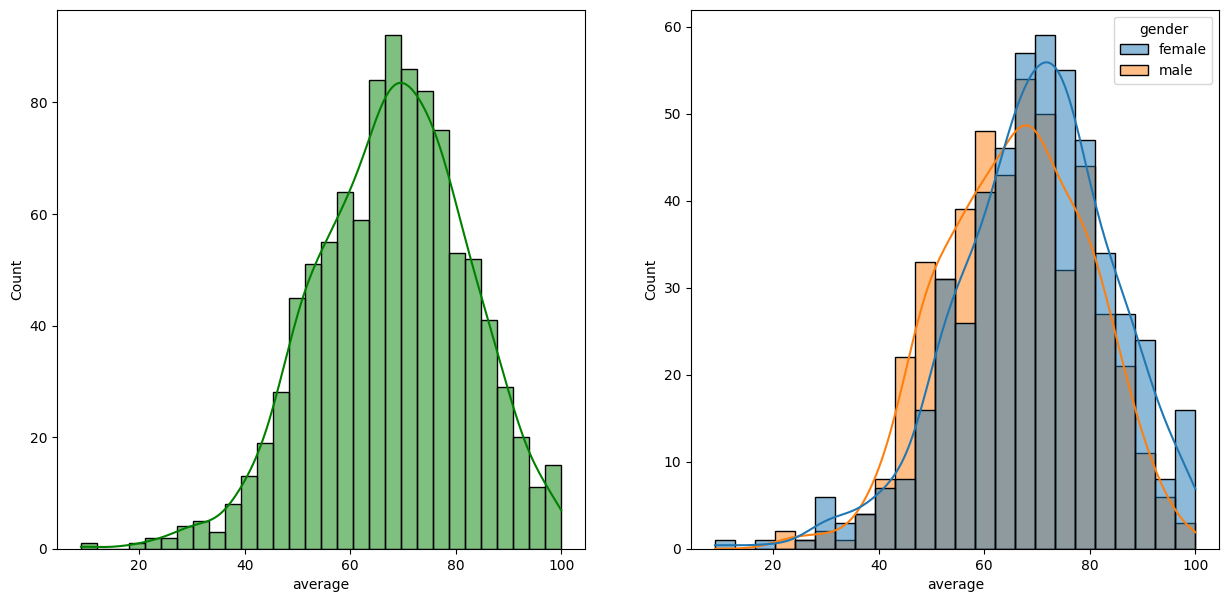

In [16]:
fig, axs = plt.subplots(1, 2, figsize = (15, 7))

sns.histplot(
    data = df,
    x = 'average',
    bins = 30,
    kde = True,
    color = 'g',
    ax = axs[0]
)

sns.histplot(
    data = df,
    x = 'average',
    kde = True,
    hue = 'gender',
    ax = axs[1]
)

plt.show()

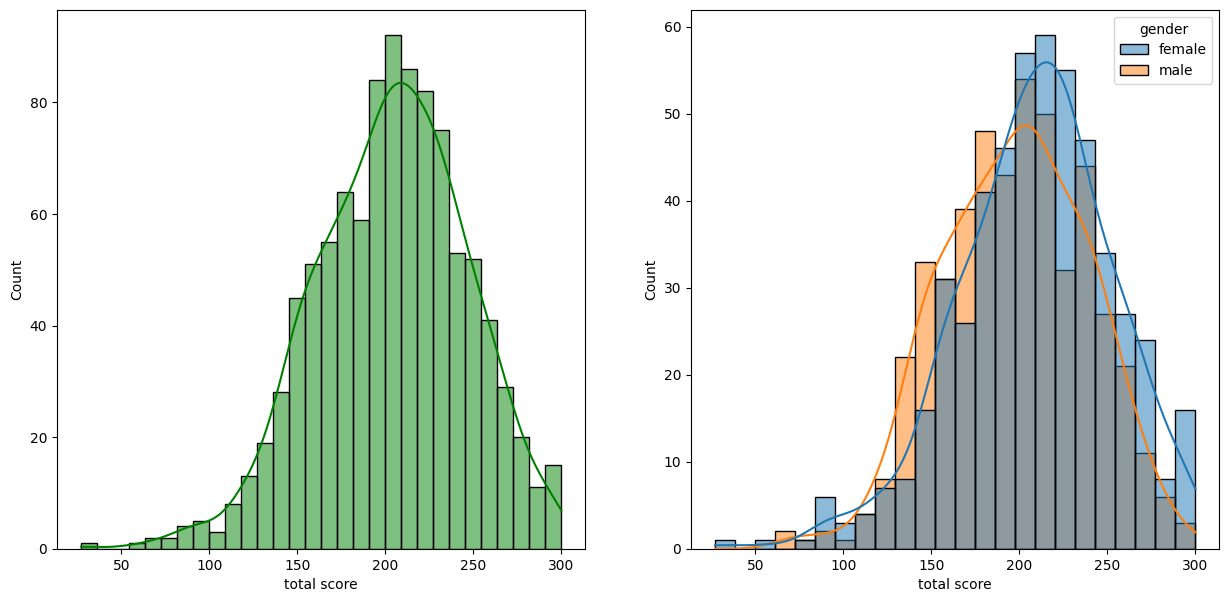

In [17]:
fig, axs = plt.subplots(1, 2, figsize = (15, 7))

sns.histplot(
    data = df,
    x = 'total score',
    bins = 30,
    kde = True,
    color = 'g',
    ax = axs[0]
)

sns.histplot(
    data = df,
    x = 'total score',
    kde = True,
    hue = 'gender',
    ax = axs[1]
)

plt.show()

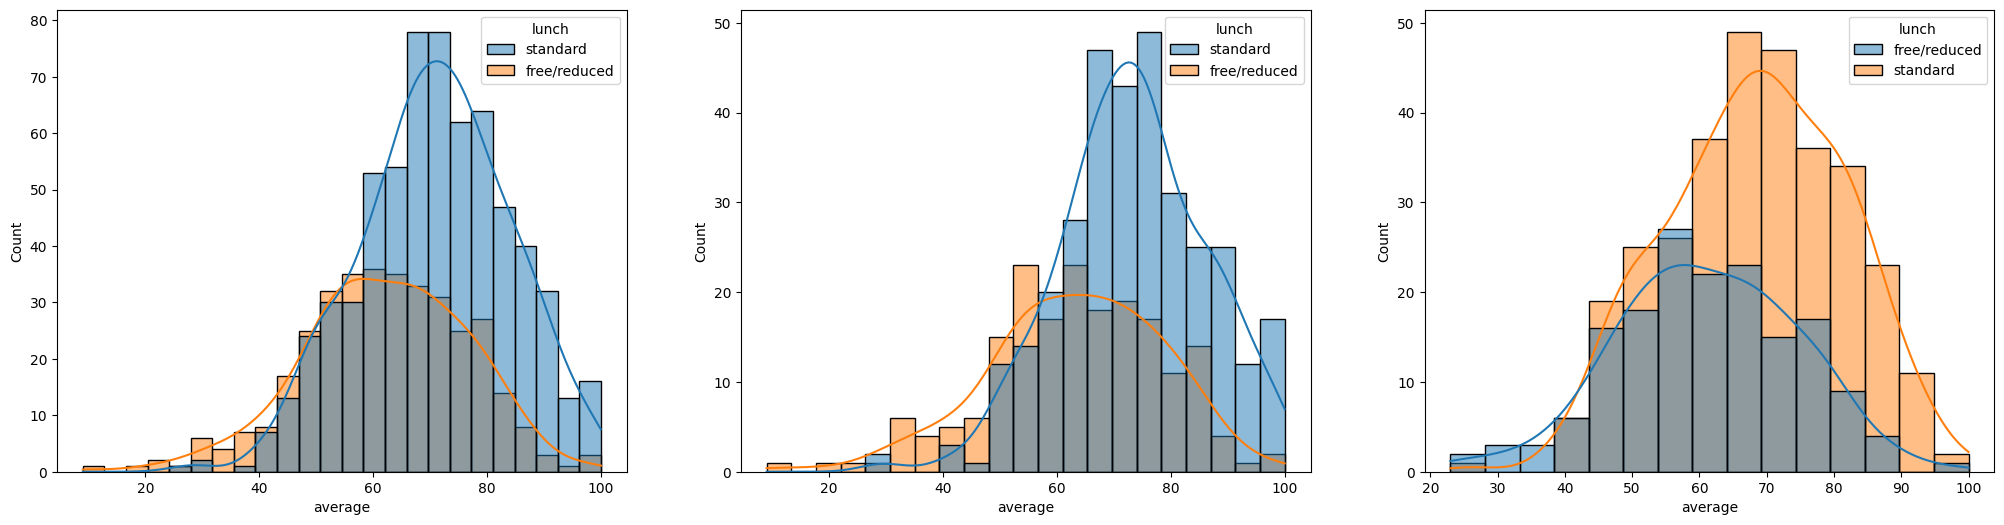

In [18]:
fig, axs = plt.subplots(1, 3, figsize = (25, 6))

sns.histplot(
    data = df,
    x = 'average',
    kde = True,
    hue = 'lunch',
    ax = axs[0]
)

sns.histplot(
    data = df[df.gender == 'female'],
    x = 'average', 
    kde = True,
    hue = 'lunch',
    ax = axs[1]
)

sns.histplot(
    data = df[df.gender == 'male'],
    x = 'average', 
    kde = True,
    hue = 'lunch',
    ax = axs[2]
)

plt.show()

**Insights**

- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exmans be it male or a female.

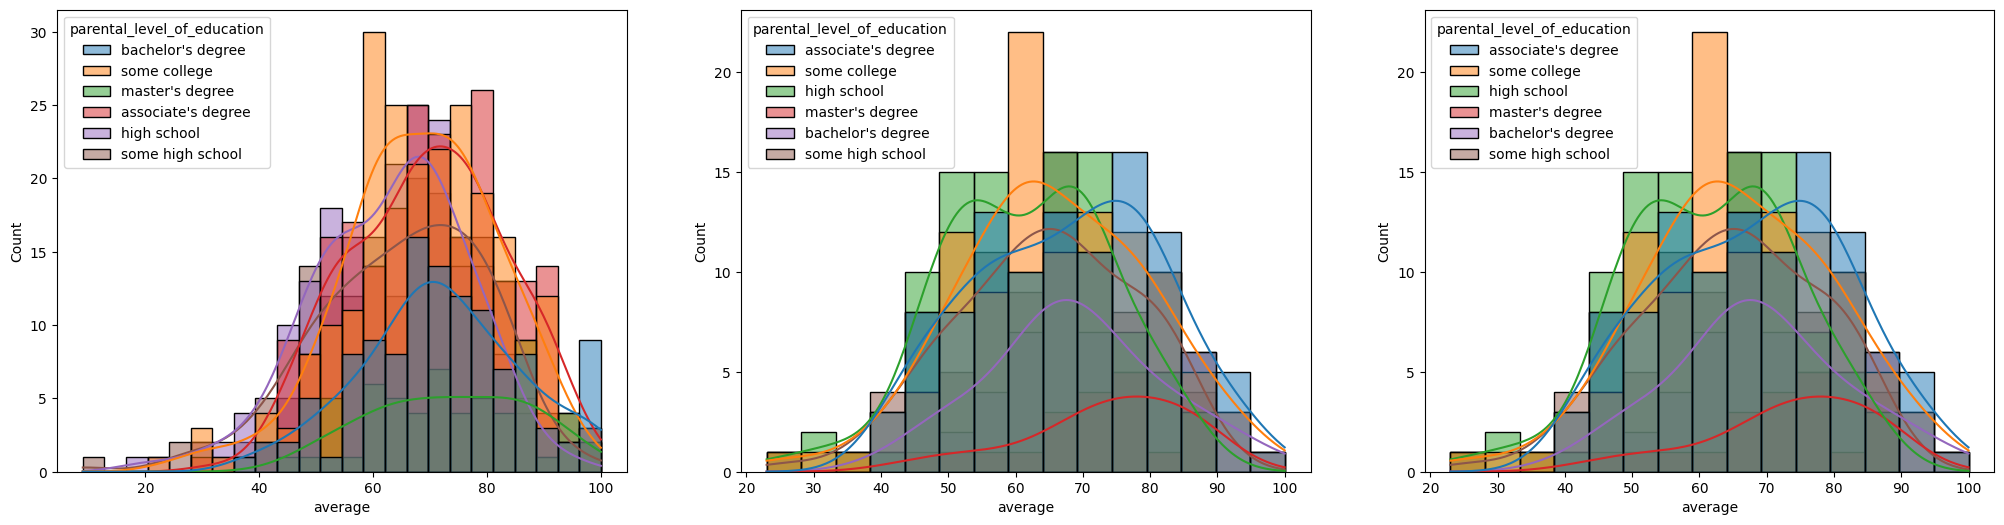

In [19]:
fig, axs = plt.subplots(1, 3, figsize = (25, 6))

sns.histplot (
    data = df,
    x = 'average',
    kde = True,
    hue = 'parental_level_of_education',
    ax = axs[0]
)

sns.histplot(
    data = df[df.gender == 'male'],
    x = 'average',
    kde = True,
    hue = 'parental_level_of_education',
    ax = axs[1]
)

sns.histplot(
    data = df[df.gender == 'male'],
    x = 'average',
    kde = True,
    hue = 'parental_level_of_education',
    ax = axs[2]
)

plt.show()

**Insights**

- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child ted to perform well in exam.
- 3rd plot, we can see there is no effect of parent's education on female students.

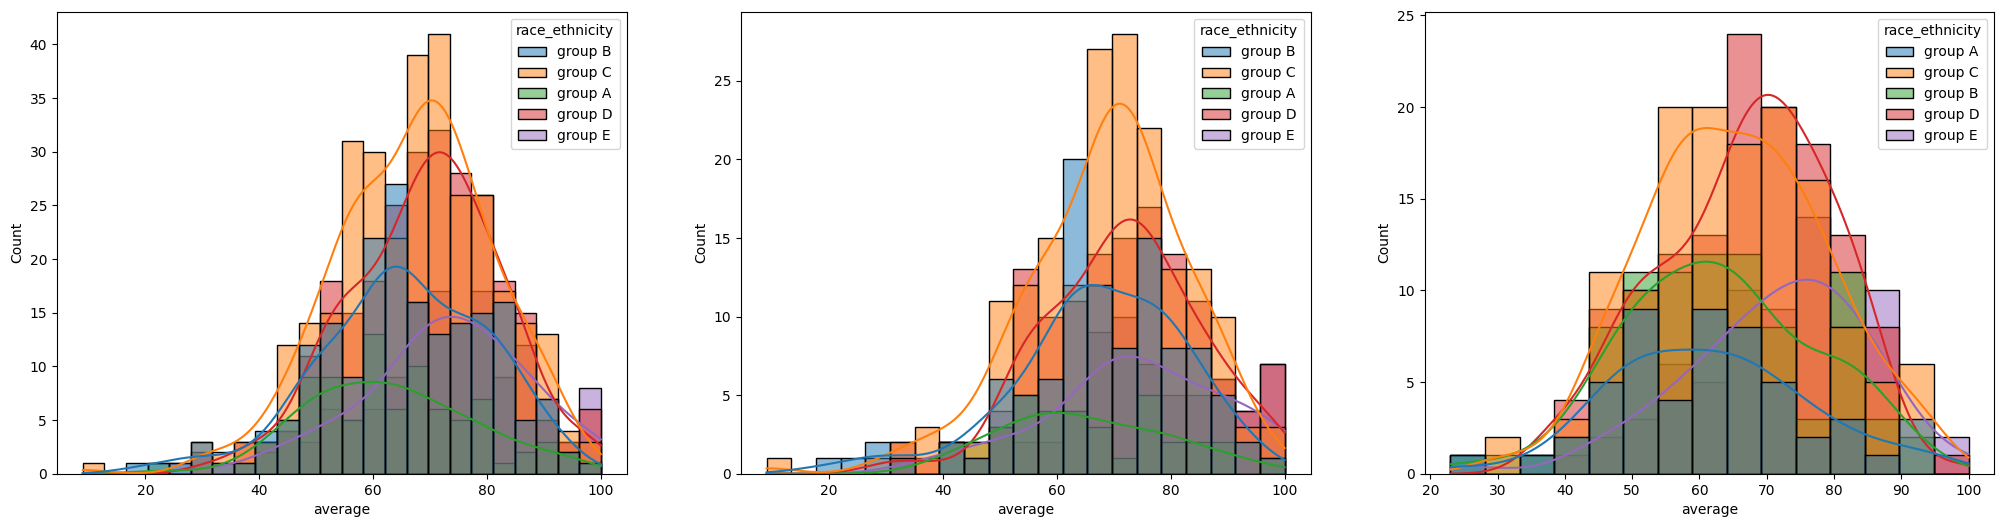

In [20]:
fig, axs = plt.subplots(1, 3, figsize = (25, 6))

sns.histplot (
    data = df,
    x = 'average',
    kde = True,
    hue = 'race_ethnicity',
    ax = axs[0]
)

sns.histplot(
    data = df[df.gender == 'female'],
    x = 'average',
    kde = True,
    hue = 'race_ethnicity',
    ax = axs[1]
)

sns.histplot(
    data = df[df.gender == 'male'],
    x = 'average',
    kde = True,
    hue = 'race_ethnicity',
    ax = axs[2]
)

plt.show()

**Insights**

- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform porrly in exam irrespective of whether they are male or female.


#### **4.2 Maximum score of studests in all three subjects** ####

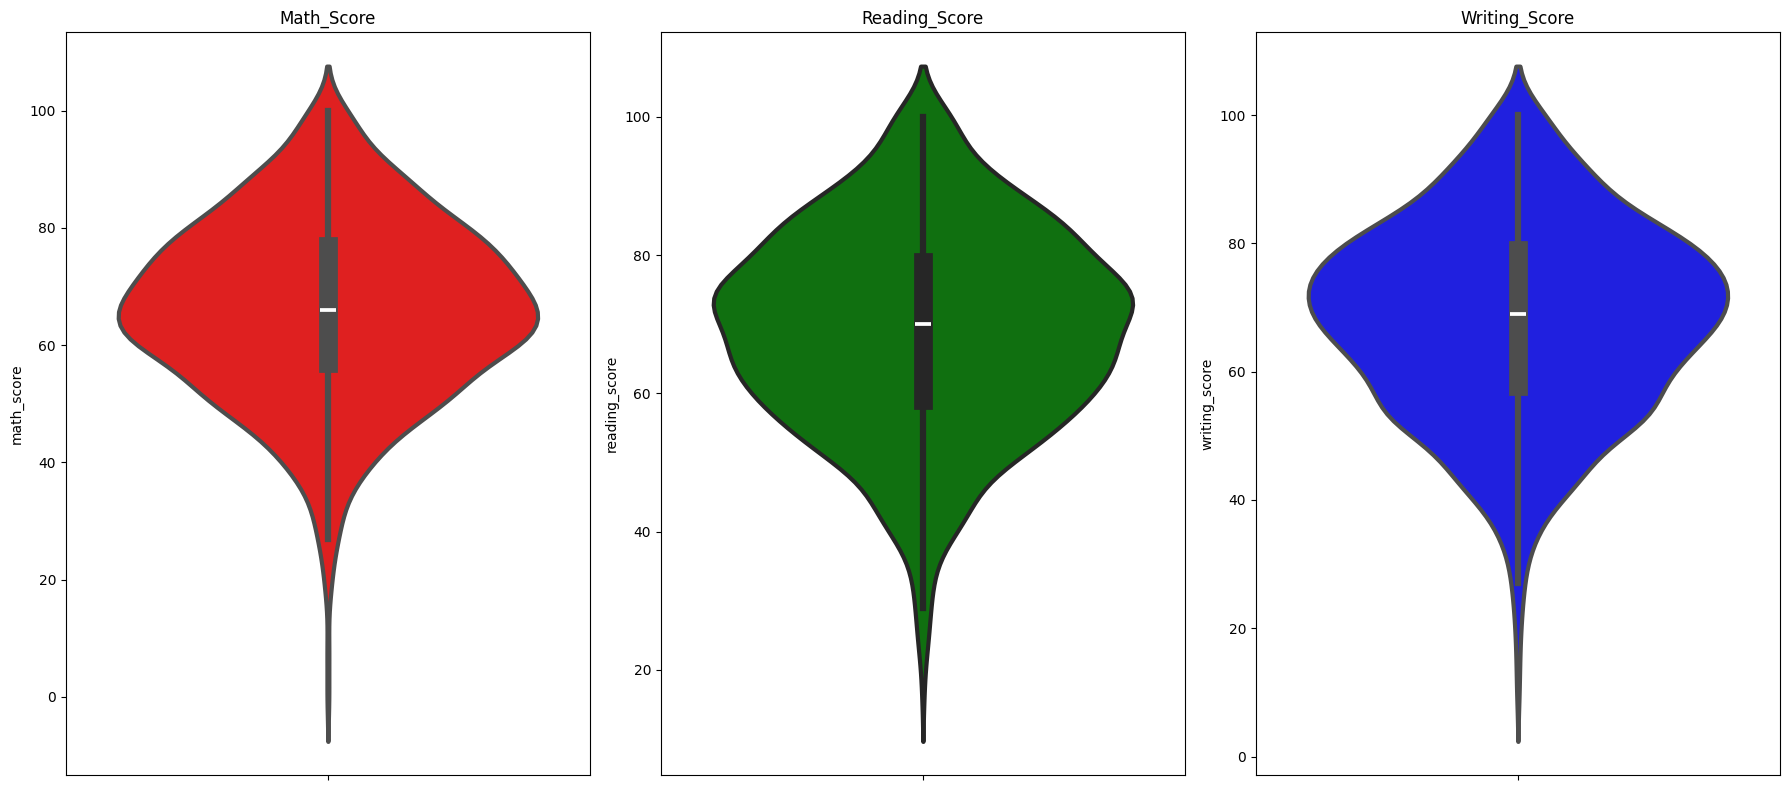

In [21]:
fig, axs = plt.subplots(1, 3, figsize = (18, 8))

scores = ['math_score', 'reading_score', 'writing_score']
colors = ['red', 'green', 'blue']

for ax, score, color in zip(axs, scores, colors) :
    sns.violinplot(
        data = df,
        y = score,
        color = color,
        linewidth = 3,
        ax = ax
    )
    ax.set_title(score.title())

plt.tight_layout()
plt.show()

**Insights**

- From the three plots above, it is clearly visible that most students score between 60 and 80 in Math, whereas in Reading and Writing, most of them score between 50 and 80.

#### **4.3 Multivariate analysis using pieplot** ####

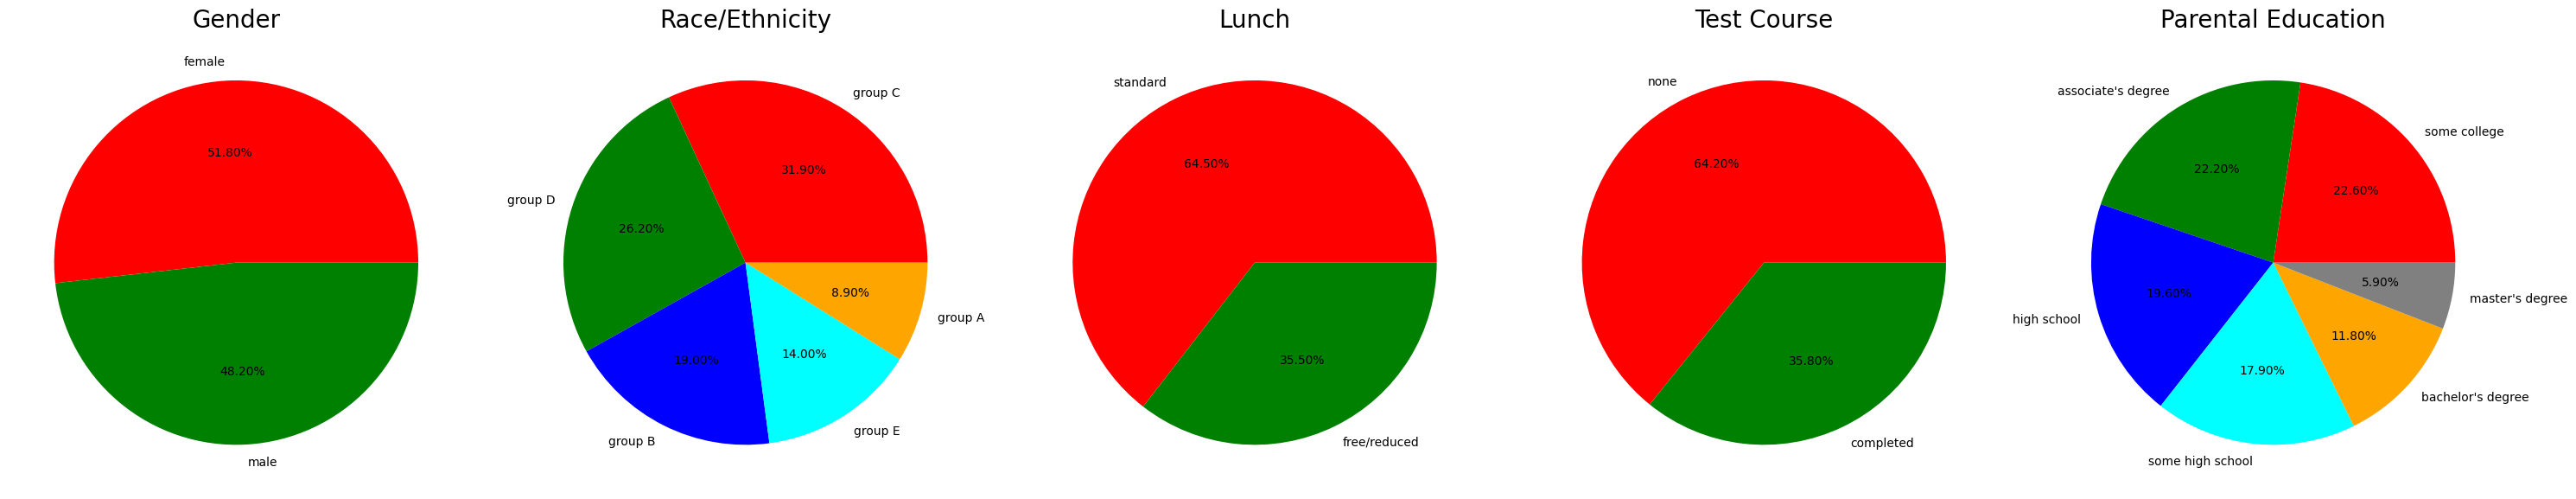

In [22]:
fig, axs = plt.subplots(1, 5, figsize = (30, 12))

columns = [
    'gender',
    'race_ethnicity',
    'lunch',
    'test_preparation_course',
    'parental_level_of_education'
]

titles = [
    'Gender',
    'Race/Ethnicity',
    'Lunch',
    'Test Course',
    'Parental Education'
]

colors = [
    ['red', 'green'],
    ['red', 'green', 'blue', 'cyan', 'orange'],
    ['red', 'green'],
    ['red', 'green'],
    ['red', 'green', 'blue', 'cyan', 'orange', 'grey']
]

for ax, column, title, color in zip(axs, columns, titles, colors) :
    size = df[column].value_counts()

    ax.pie(
        size,
        colors = color,
        labels = size.index,
        autopct = '%.2f%%'
    )

    ax.set_title(title, fontsize = 20)
    ax.axis('off')

plt.tight_layout()
plt.show()

**Insights**

- Number of Male and Female students is almost equal;
- Number of students are greatest in Group C;
- Number of students who have standard lunch are greater;
- Number of students who have not enrolled in any test preparation course is greater;
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree".

#### **4.4 Feature Wise visualization** ####

**4.4.1 Gender Column**

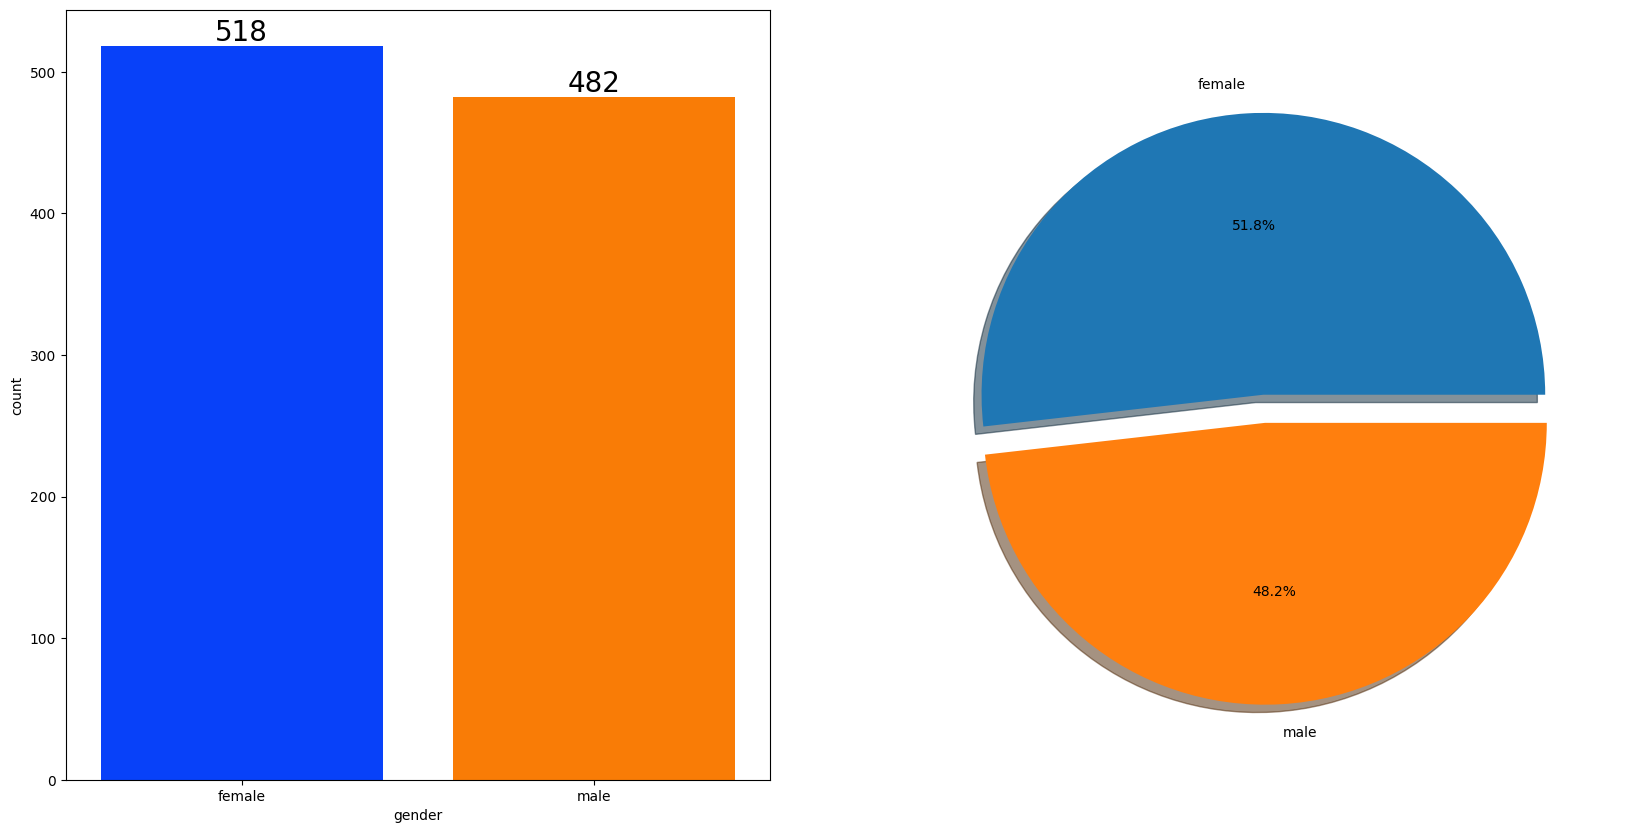

In [23]:
fig, axs = plt.subplots(1, 2, figsize = (20,10))

sns.countplot(
    data = df,
    x = 'gender',
    palette = 'bright',
    ax = axs[0],
    saturation = 0.95
)

for container in axs[0].containers :
    axs[0].bar_label(
        container,
        color = 'black',
        size = 20
    )

gender_couts = df['gender'].value_counts()

axs[1].pie(
    gender_couts,
    labels = gender_couts.index,
    autopct = '%1.1f%%',
    explode = [0, 0.1],
    shadow = True
)

plt.show()

**Insights**

- Gender has balanced data with female students are 518 (51.8%) and male studests are 482 (48.2%).

#### **BIVARIATE ANALYSIS (Is gender has any impact on student's performance?** ####

In [24]:
gender_group = df.groupby('gender').mean(numeric_only = True)
gender_group

,math_score,reading_score,writing_score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


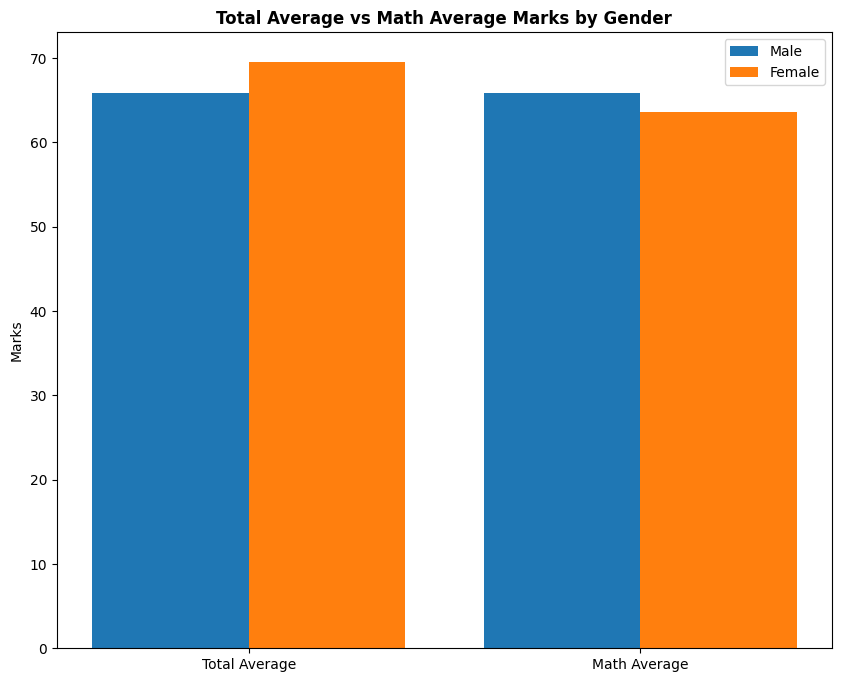

In [25]:
x = ['Total Average', 'Math Average']

female_scores = [
    gender_group.loc['female', 'average'],
    gender_group.loc['female', 'math_score']
]

male_scores = [
    gender_group.loc['male', 'average'],
    gender_group.loc['male', 'average']
]

x_axis = np.arange(len(x))

plt.figure(figsize = (10, 8))

plt.bar(x_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(x_axis + 0.2, female_scores, 0.4, label = 'Female')

plt.xticks(x_axis, x)
plt.ylabel('Marks')
plt.title(
    'Total Average vs Math Average Marks by Gender',
    fontweight = 'bold'
)
plt.legend()

plt.show()

**Insights**

- On average, females have better overall score than men.
- Whereas, males have scored higher in Maths


#### **4.4.2 RACE/ETHNICITY COLUMN** ####

**UNIVARIATE ANALYSIS (How is group wise distribution)**

<function matplotlib.pyplot.show(close=None, block=None)>

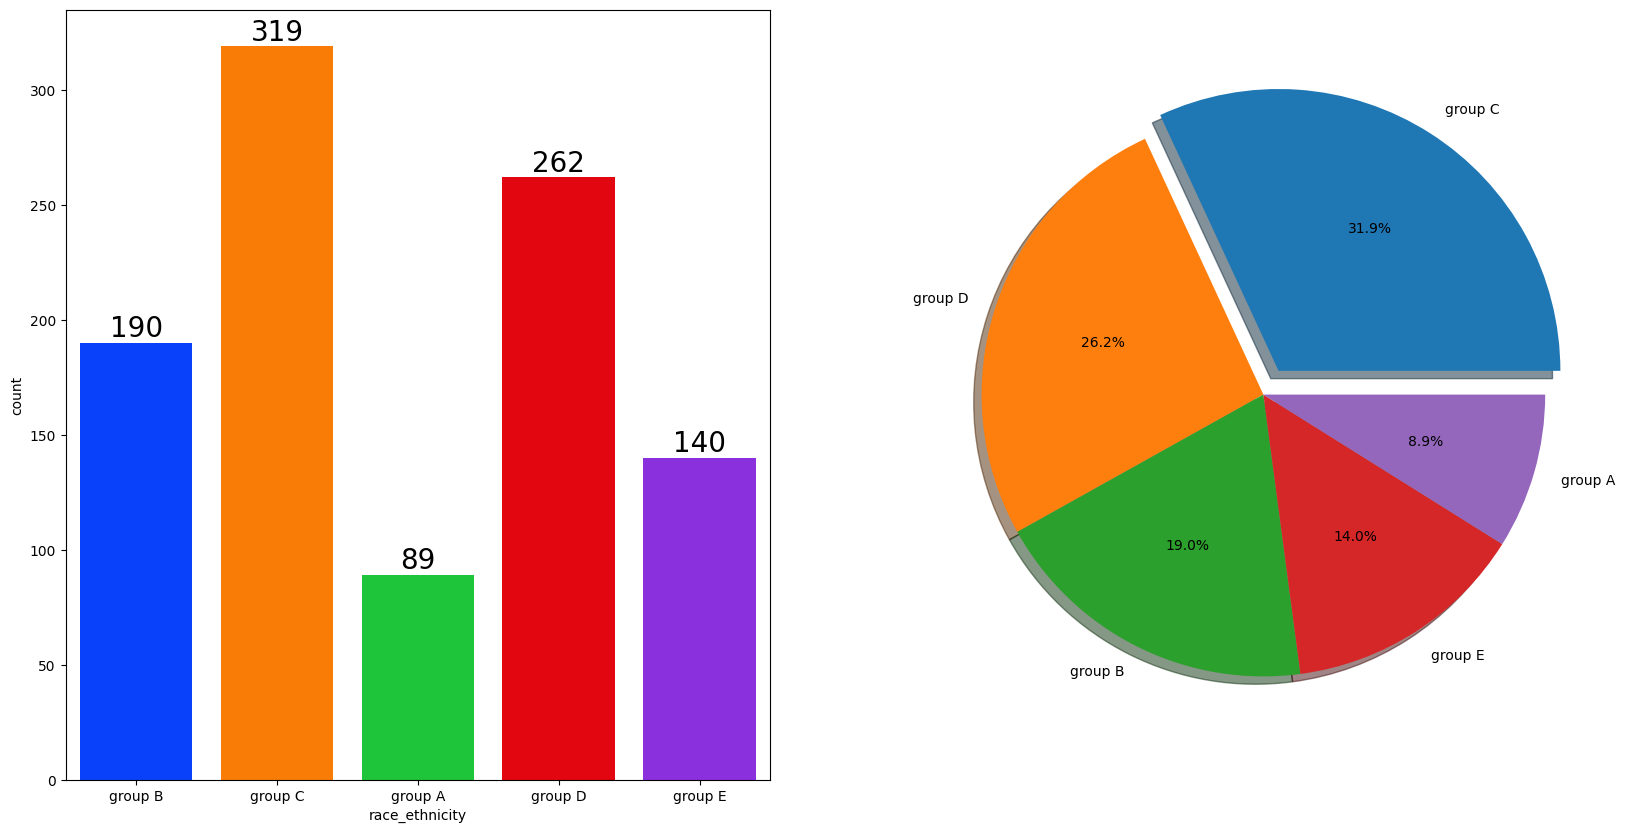

In [26]:
fig, axs = plt.subplots(1, 2, figsize = (20,10))

sns.countplot(
    x = df['race_ethnicity'],
    data = df,
    palette = 'bright',
    ax = axs[0],
    saturation = 0.95
)

for container in axs[0].containers :
    axs[0].bar_label(
        container, 
        color = 'black',
        size = 20
    )

race_counts = df['race_ethnicity'].value_counts()

axs[1].pie(
    race_counts,
    labels = race_counts.index,
    explode = [0.1, 0, 0, 0, 0],
    autopct = '%1.1f%%',
    shadow = True
)

plt.show

**Insights**

- Most of the students belong to group C/D.
- Lowest number of students belong to group A.

**BIVARIATE ANALYSIS (Is race_ethnicity has any impact on student's performance?**

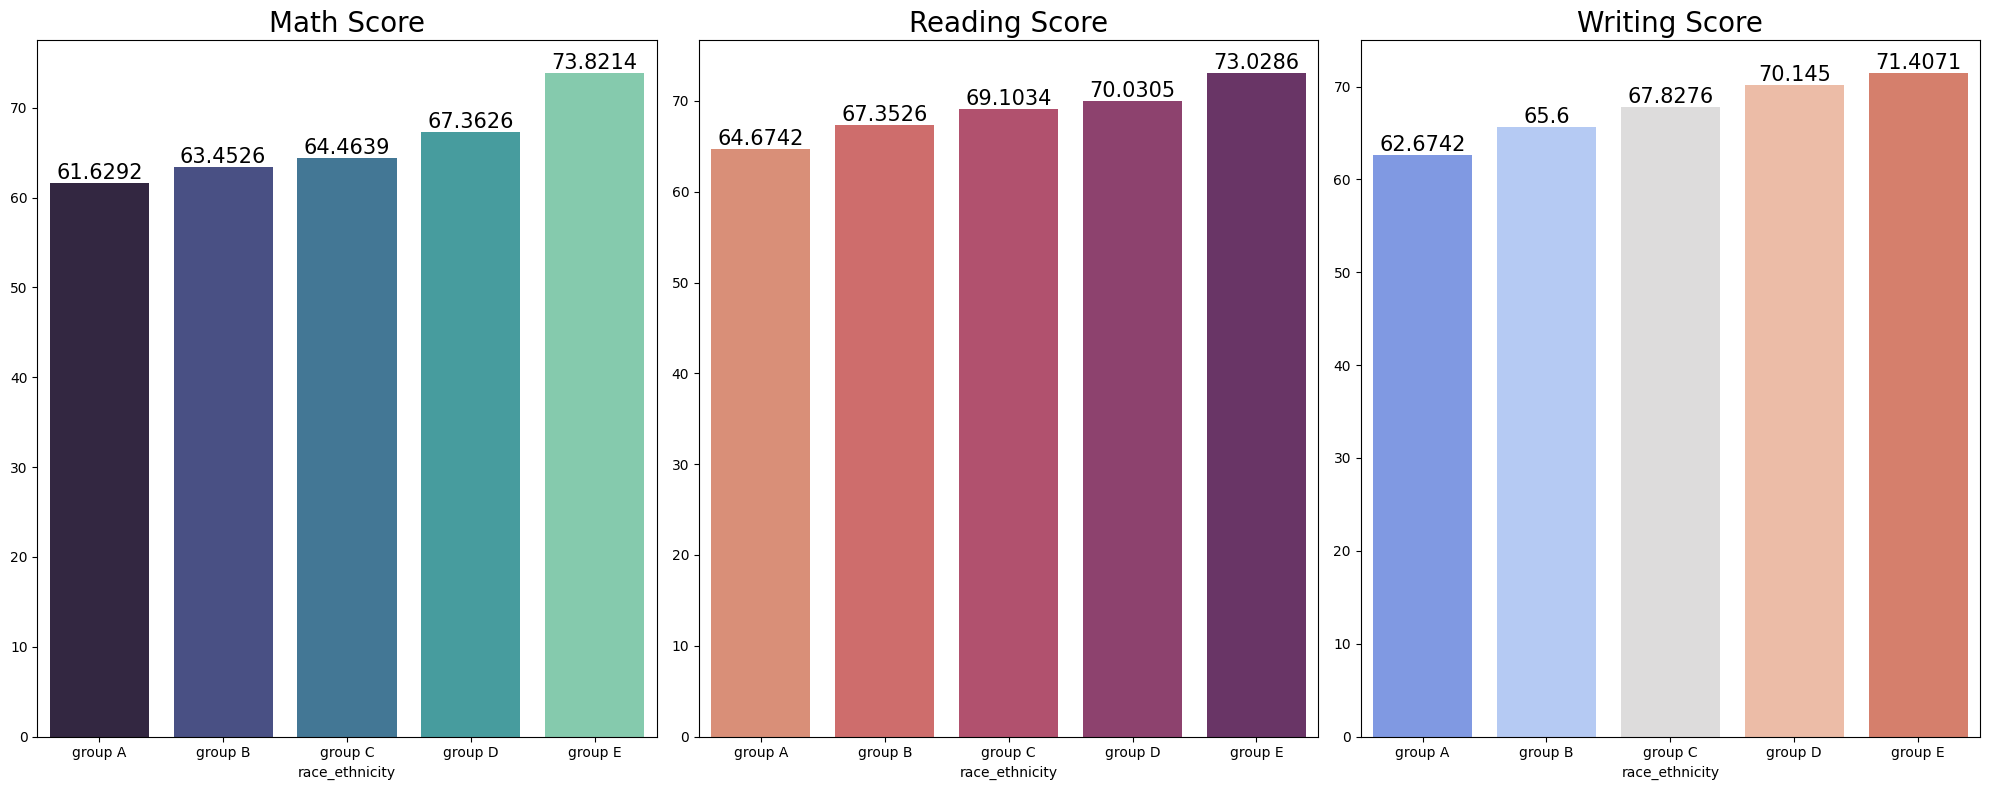

In [27]:
group_data = df.groupby('race_ethnicity')

scores = {
    'Math Score' : group_data['math_score'].mean(),
    'Reading Score' : group_data['reading_score'].mean(),
    'Writing Score' : group_data['writing_score'].mean()
}

palettes = ['mako', 'flare', 'coolwarm']

fig, axs = plt.subplots(1, 3, figsize = (20, 8))

for i, (title, data) in enumerate(scores.items()) :

    sns.barplot(
        x = data.index,
        y = data.values,
        palette = palettes[i],
        ax = axs[i]
    )

    axs[i].set_title(title, size = 20)

    for container in axs[i].containers :
        axs[i].bar_label(container, size = 15)

plt.tight_layout()
plt.show()

**Insights**

- Group E students have scored the highest marks.
- Group A students have scored the lowest marks.
- Students from a lower socioeconomic status have a lower avg in all course subjects.


#### **4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN** ####

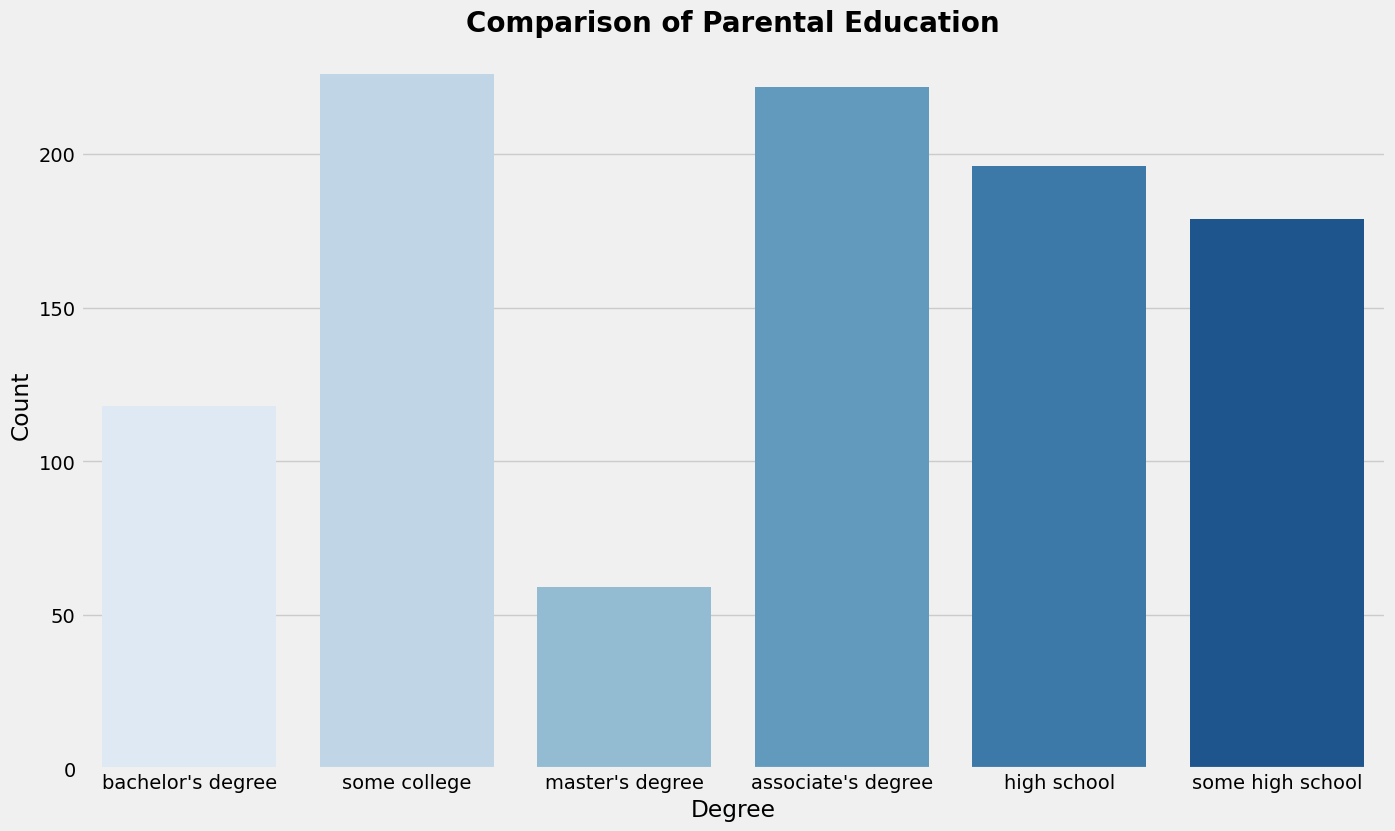

In [28]:
plt.style.use('fivethirtyeight')

plt.figure(figsize = (15, 9))

sns.countplot(
    data = df,
    x = 'parental_level_of_education',
    palette = 'Blues'
)

plt.title(
    'Comparison of Parental Education',
    fontsize = 20,
    fontweight = 'bold'
)

plt.xlabel('Degree')
plt.ylabel('Count')

plt.show()

**Insights**

- Largest number of parents are from some college.


**BIVARIATE ANALYSIS (Is parental education has any impact on student's performance ?**

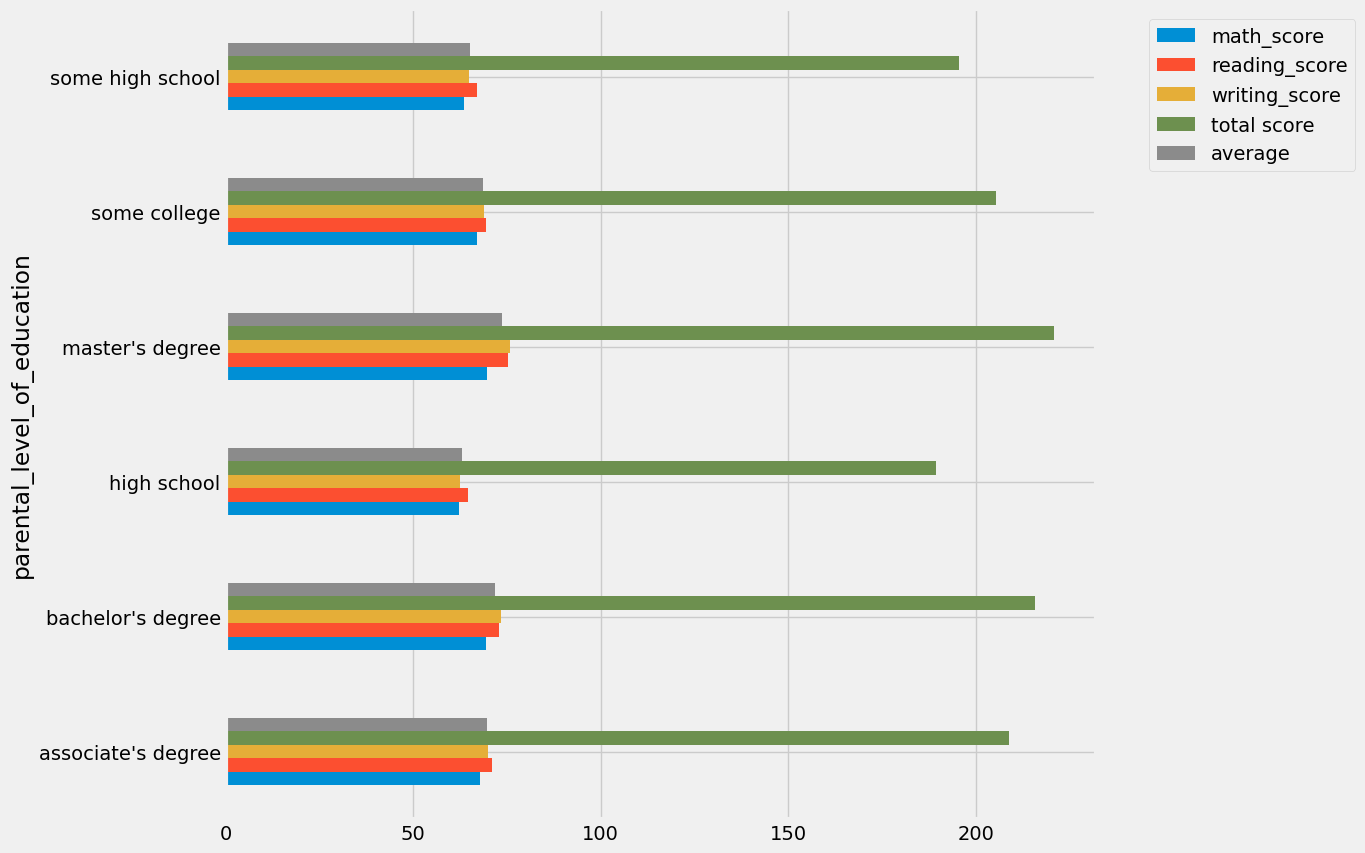

In [29]:
grouped_data = df.groupby('parental_level_of_education')

mean_data = grouped_data.mean(numeric_only = True)

mean_data.plot(
    kind = 'barh',
    figsize = (10,10)
)

plt.legend(
    bbox_to_anchor = (1.05, 1),
    loc = 'upper left'
)

plt.show()

**Insights**

- The score of students whose parents possess master and bachelor level education are higher than others.

#### **4.4.4 LUNCH COLUMN** ####

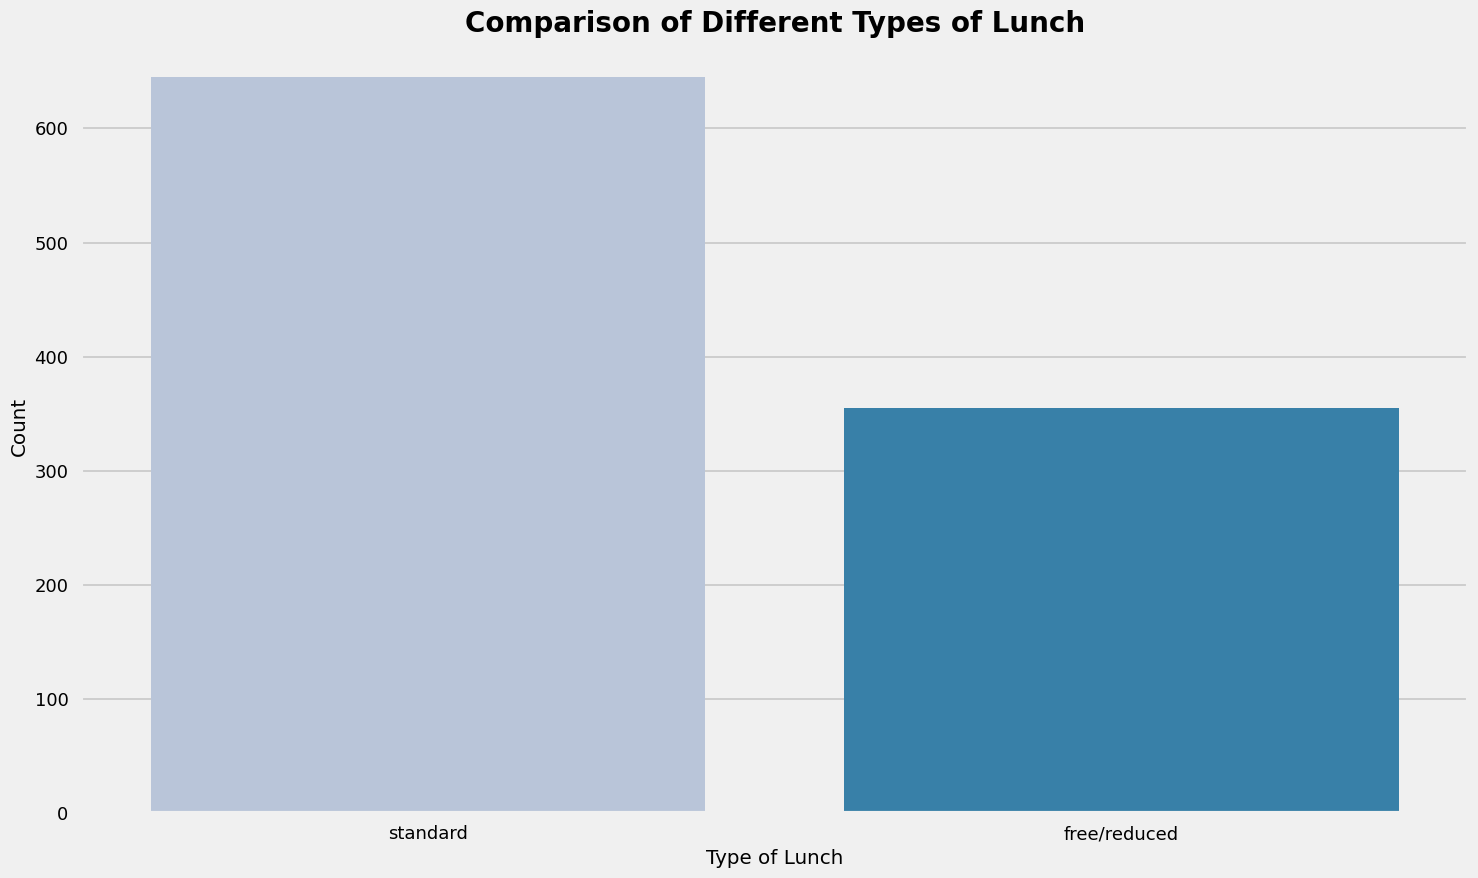

In [30]:
plt.style.use('seaborn-talk')

plt.figure(figsize = (15, 9))

sns.countplot(
    data = df,
    x = 'lunch',
    palette = 'PuBu'
)

plt.title(
    'Comparison of Different Types of Lunch',
    fontsize = 20,
    fontweight = 'bold'
)

plt.xlabel('Type of Lunch')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Insights**

- Students being served standard lunch was more than free lunch.

**BIVARIATE ANALYSIS (Is lunch type intake has nay impact on student's performance?**

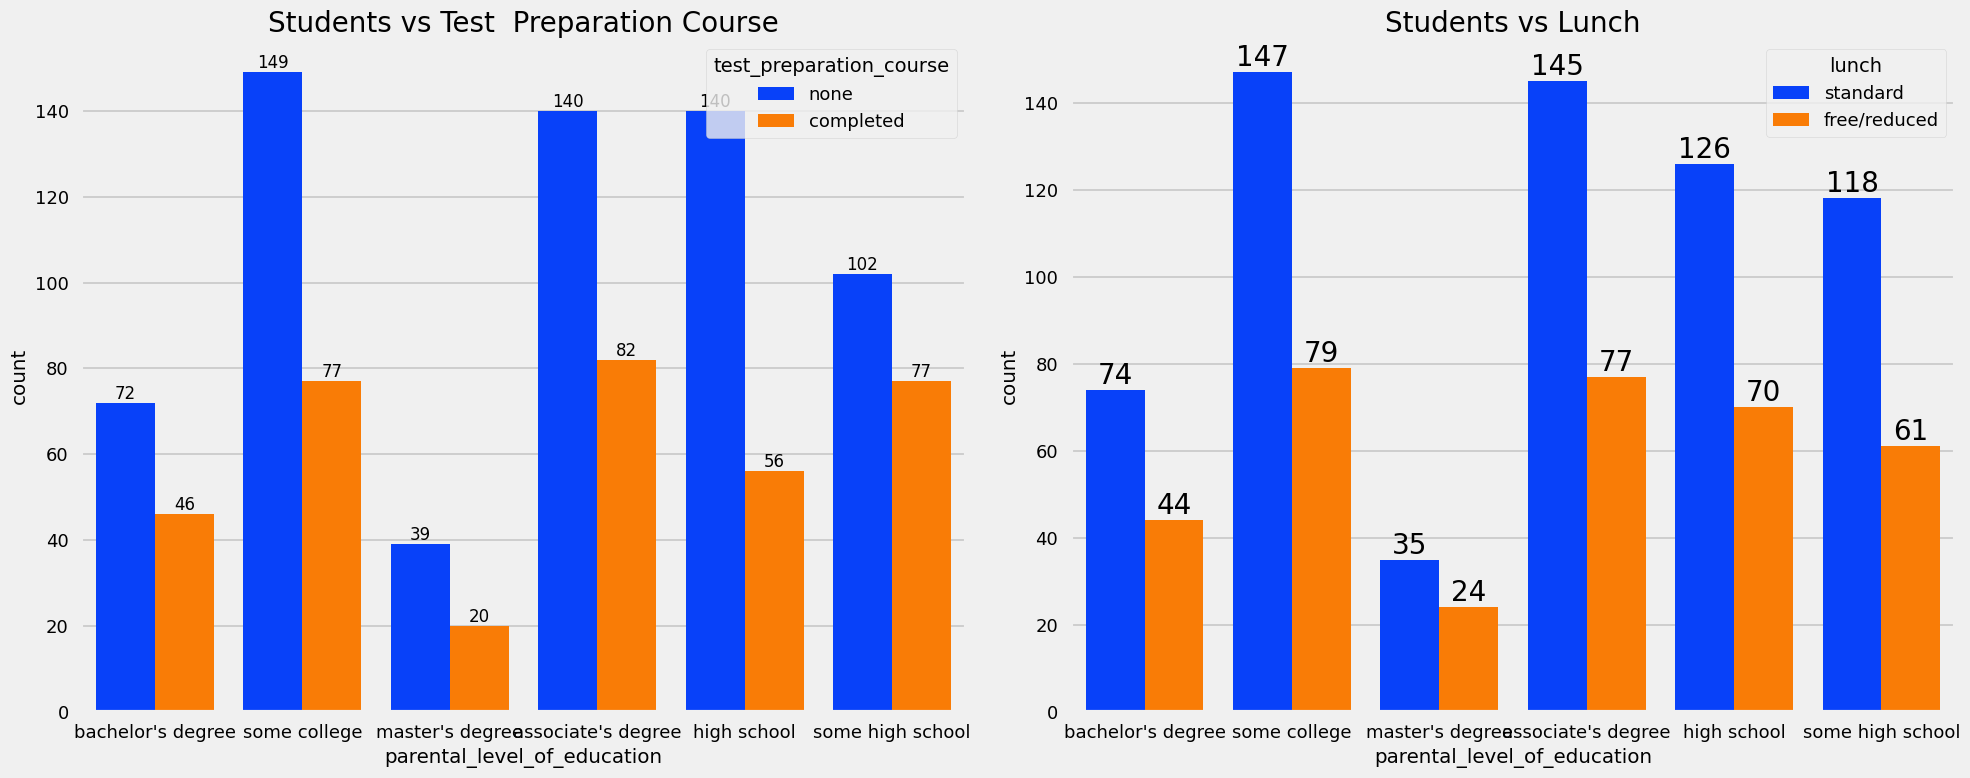

In [31]:
fig, axs = plt.subplots(1, 2, figsize = (20, 8))

sns.countplot( 
    data = df, 
    x = df['parental_level_of_education'],
    hue = 'test_preparation_course', 
    palette = 'bright',
    saturation = 0.95, 
    ax = axs[0]
)

axs[0].set_title(
    'Students vs Test  Preparation Course',
    fontsize = 20
)

for container in axs[0].containers :
    axs[0].bar_label(
        container,
        color = 'black',
        size = 12
    )

sns.countplot(
    data = df,
    x = df['parental_level_of_education'],
    hue = 'lunch',
    palette = 'bright',
    saturation = 0.95,
    ax = axs[1]
)

axs[1].set_title(
    'Students vs Lunch',
    fontsize = 20
)

for container in axs[1].containers :
    axs[1].bar_label(
        container, 
        color = 'black',
        size = 20
    )

plt.tight_layout()
plt.show()

**Insights**

- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### **4.4.5 TEST PREPARATION COURSE COLUMN** ####

**BIVARIATE ANALYSIS (Is test preparation course has any impact on student's performance?**

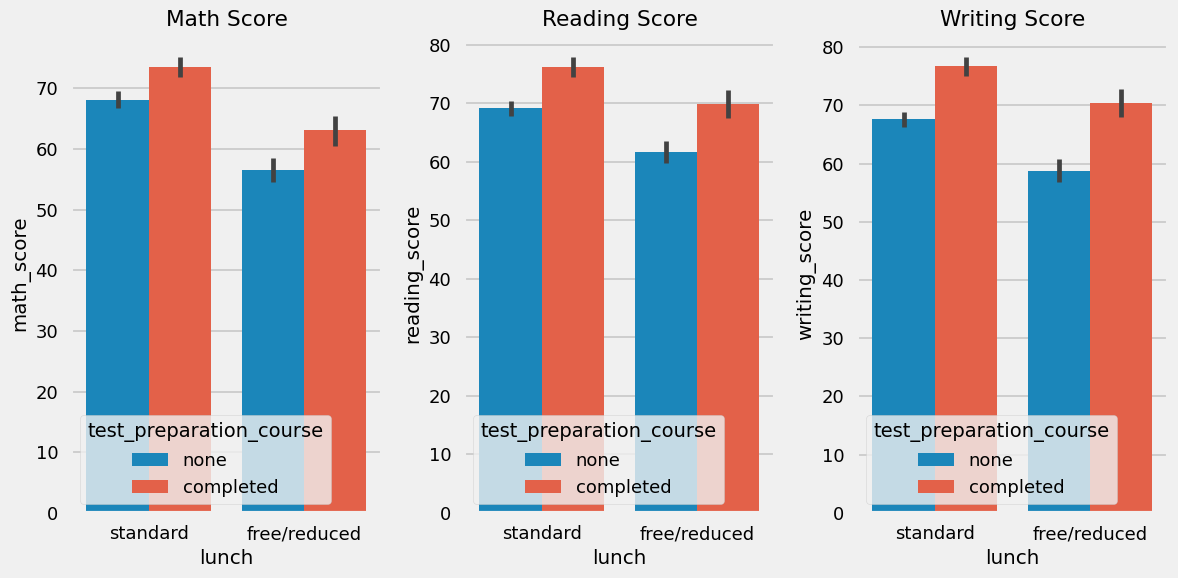

In [35]:
fig, axs = plt.subplots(1, 3, figsize = (12, 6))

scores = [
    'math_score',
    'reading_score',
    'writing_score'
]

titles = [
    'Math Score',
    'Reading Score',
    'Writing Score'
]

for i, (score, title) in enumerate(zip(scores, titles)) :
    sns.barplot(
        data = df,
        x = 'lunch',
        y = score,
        hue = 'test_preparation_course',
        ax = axs[i]
    )

    axs[i].set_title(title)

plt.tight_layout()
plt.show()

**Insights**

 - Students who have completed the test preparation course have scores higher in all three categories than who haven't taken the course.

#### **4.4.6 CHECKING OUTLIERS** ####

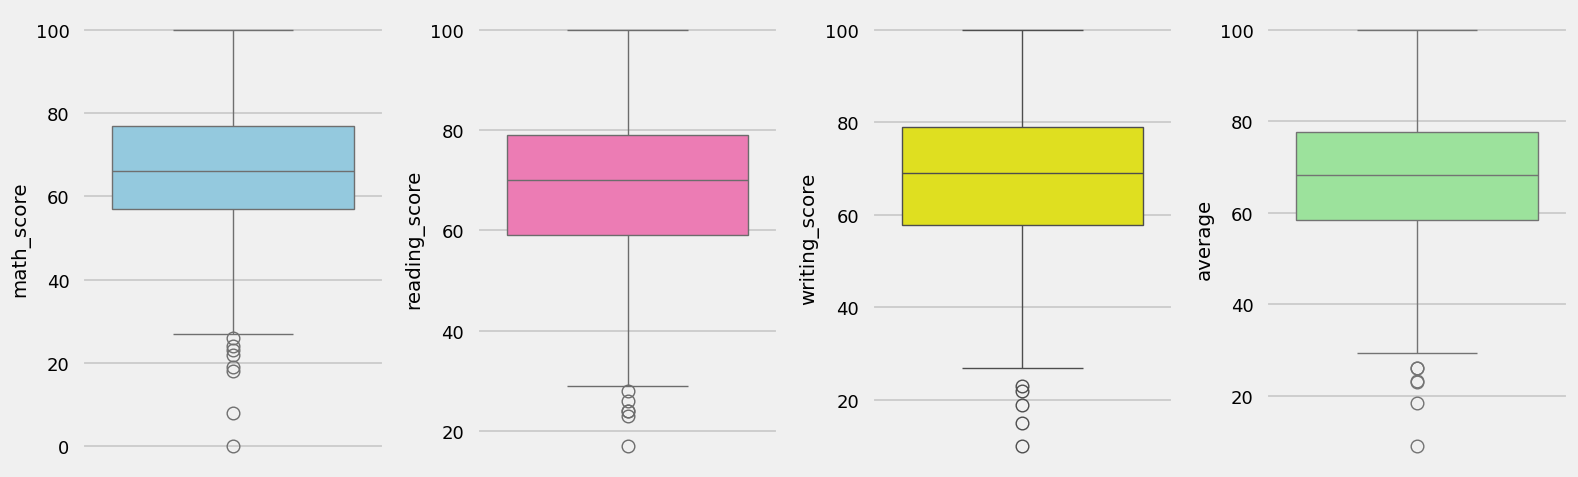

In [38]:
fig, axs = plt.subplots(1, 4, figsize = (16, 5))

scores_colors = {
    'math_score' : 'skyblue',
    'reading_score' : 'hotpink',
    'writing_score' : 'yellow',
    'average' : 'lightgreen'
}

for i, (score, color) in enumerate(scores_colors.items()) :
    sns.boxplot(
        data = df,
        y = score,
        color = color,
        ax = axs[i]
    )

plt.tight_layout()
plt.show()

#### **4.4.7 MULTIVARIATE ANALYSIS USING PAIRPLOT** ####

In [41]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


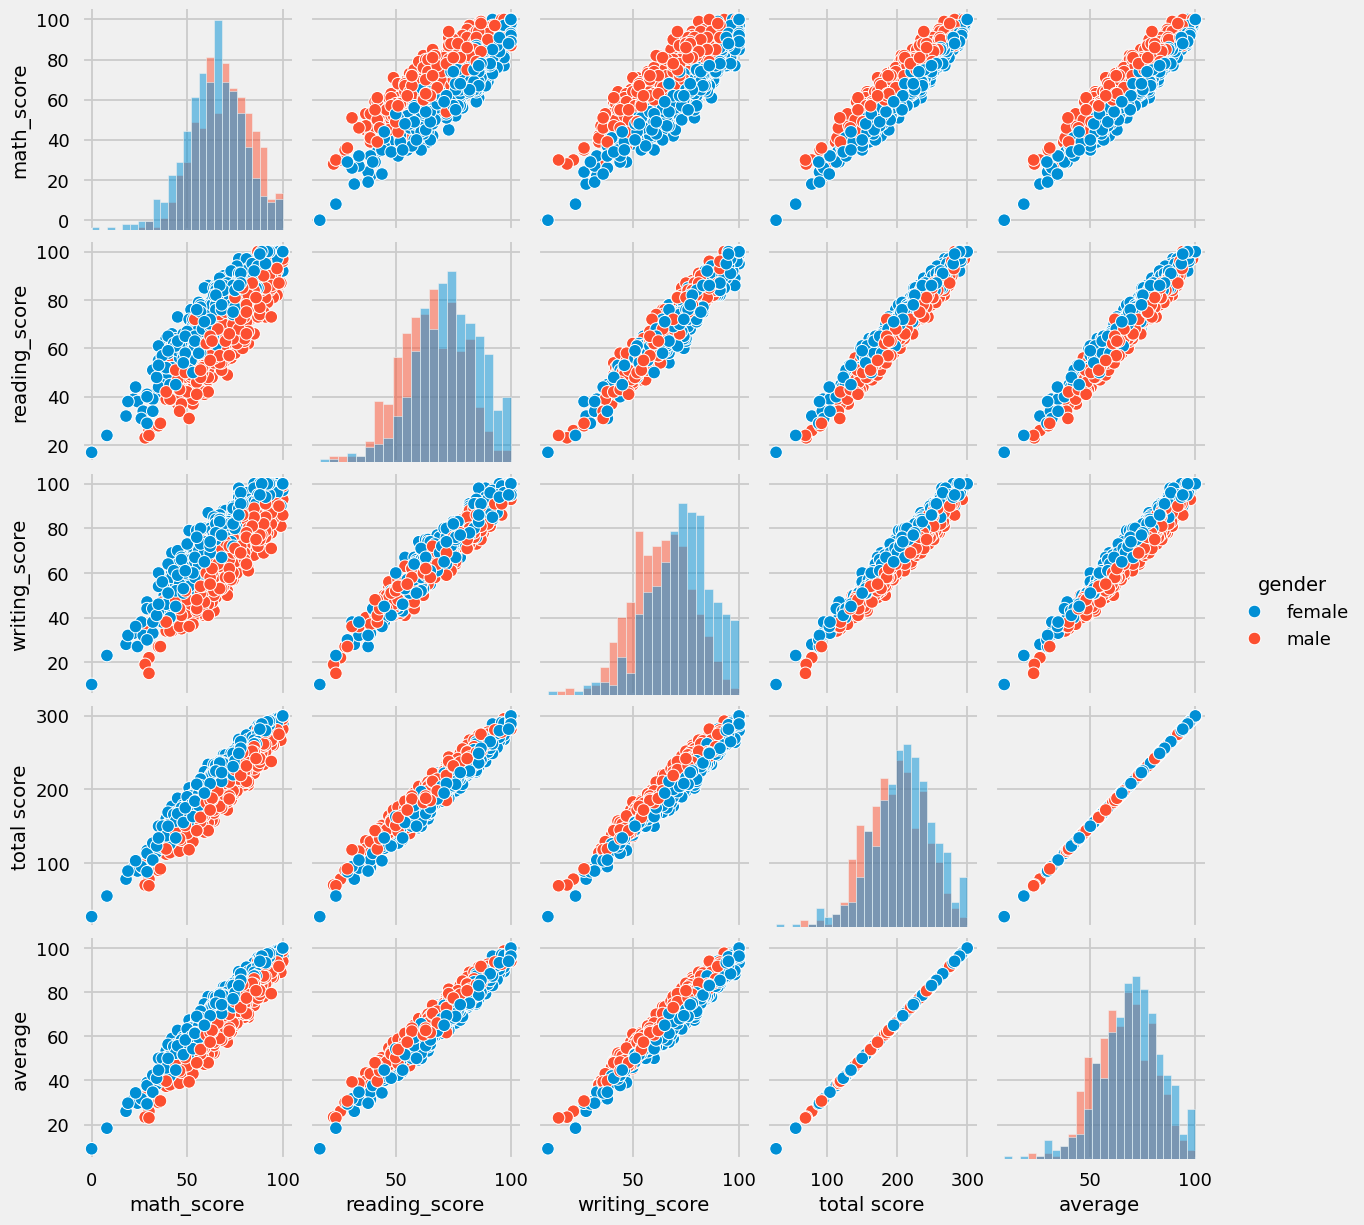

In [42]:
score_columns = [
    'math_score',
    'reading_score',
    'writing_score',
    'total score',
    'average'
]

sns.pairplot(
    data=df,
    vars=score_columns,
    hue='gender',
    diag_kind='hist'
)

plt.show()

**Insights**

- From the above plot it is clear that all the scores increase linearly with each other.

#### **5. Conclusions** ####

- Student's performance is realted with lunch, race and parental level of education.
- Females lead is pass percentage and alse are top-scorers.
- Student's performance is not much related with test preparation course.
- Finishing preparation course is benefitial.